## Exploratory Data Analysis

Importing required libraries and loading the training dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


cols_to_remove = ["FarmerID"]

train = train.loc[:, ~train.columns.str.contains("^Unnamed")]
test  = test.loc[:, ~test.columns.str.contains("^Unnamed")]

train = train.drop(columns=cols_to_remove, errors="ignore")
test  = test.drop(columns=cols_to_remove, errors="ignore")
df = train.copy()

Analysis of the dataset

In [ ]:
df.head()

,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,Address type,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,MADHYA PRADESH,CENTRAL,M,BARELI,464668,RAISEN,Seoni,M,NaN,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,97.24,19.50,0.95,22.38,33.53,Poor,0.77,0.00,1360000
1,BIHAR,EAST,M,BANDRA,848125,MUZAFFARPUR,Namapur,M,NaN,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.96,16.76,0.97,24.63,37.17,Poor,0.45,0.00,807200
2,MADHYA PRADESH,CENTRAL,M,MALHARGARH,458556,MANDSAUR,Billaud,M,NaN,NaN,...,CENTRAL HIGHLANDS ( MALWA ) GUJARAT PLAIN AND...,90.05,22.44,0.95,19.49,28.85,Poor,0.66,0.00,500000
3,MAHARASHTRA,WEST,M,RENAPUR,413527,LATUR,Renapur,M,NaN,NaN,...,DECCAN PLATU HOT SEMI-ARID ECO-REGION,94.64,21.48,0.98,31.84,48.85,Average,0.24,2.49,558000
4,MADHYA PRADESH,CENTRAL,F,KHURAI,470117,SAGAR,Singhpur,M,NaN,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,95.90,18.93,0.97,21.33,31.82,Poor,0.21,0.00,800000


Comparing a numerical heatmap

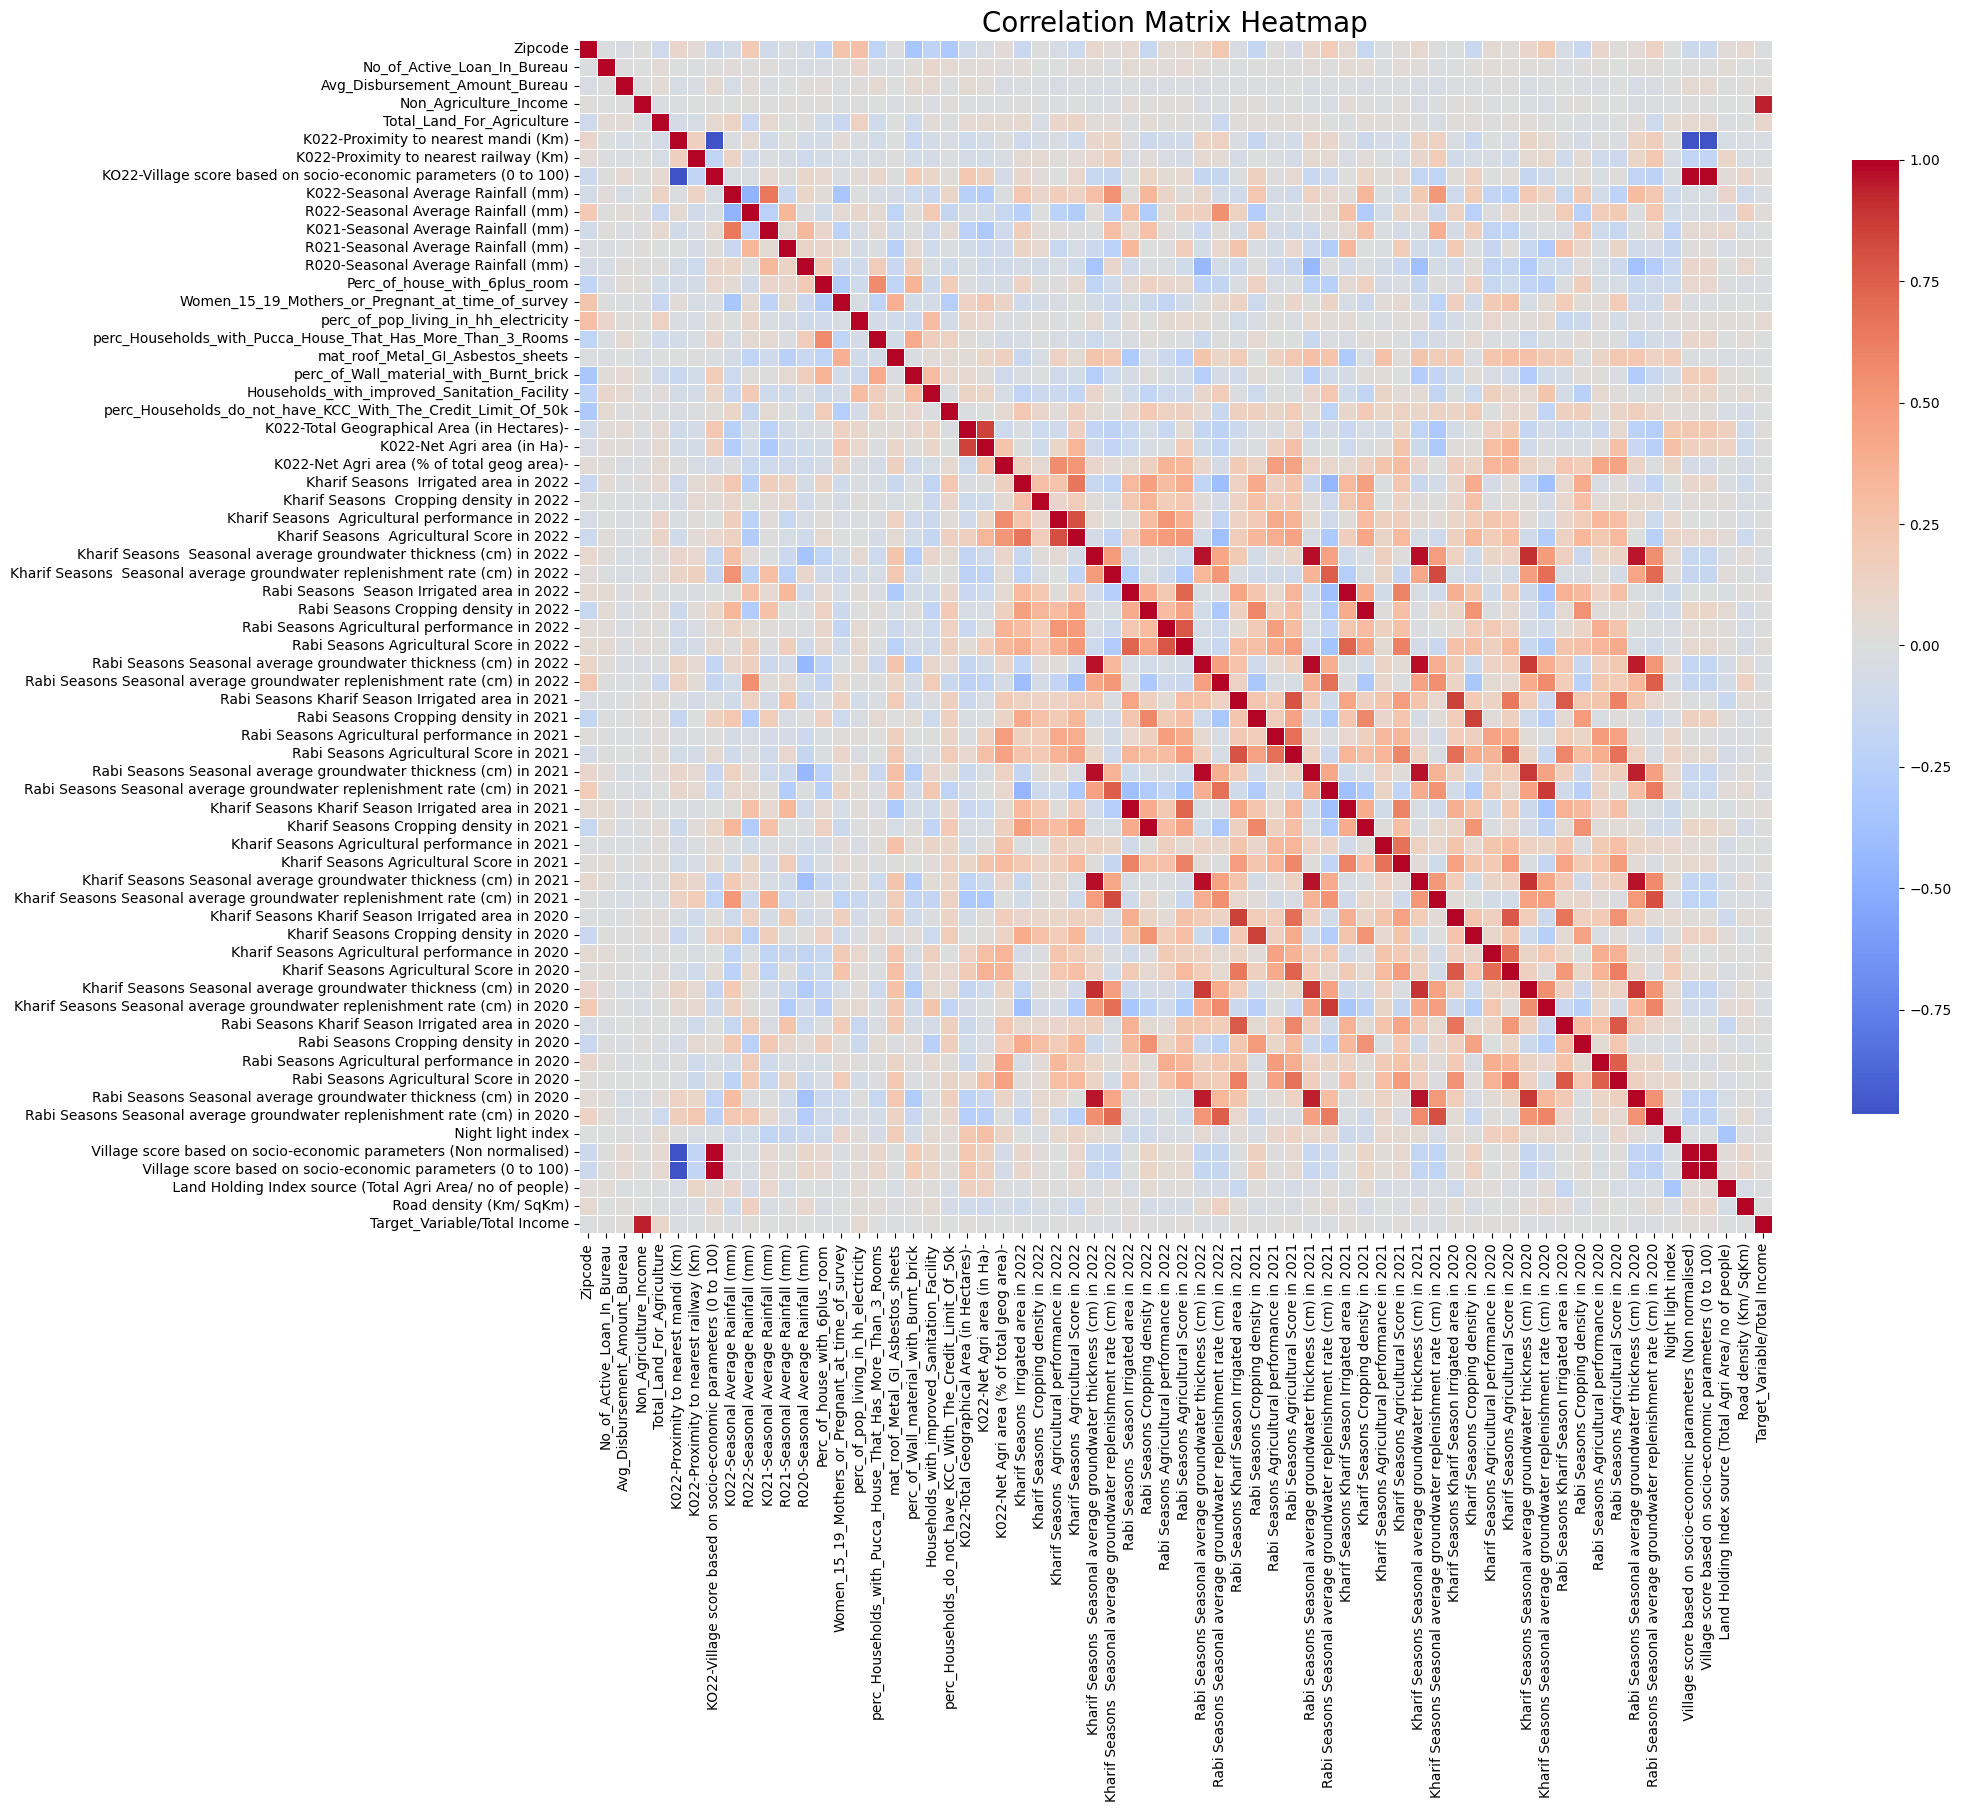

In [ ]:

df = df.iloc[:,1:]

numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

plt.figure(figsize=(22,18))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix Heatmap", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Checking missing values with bar graph

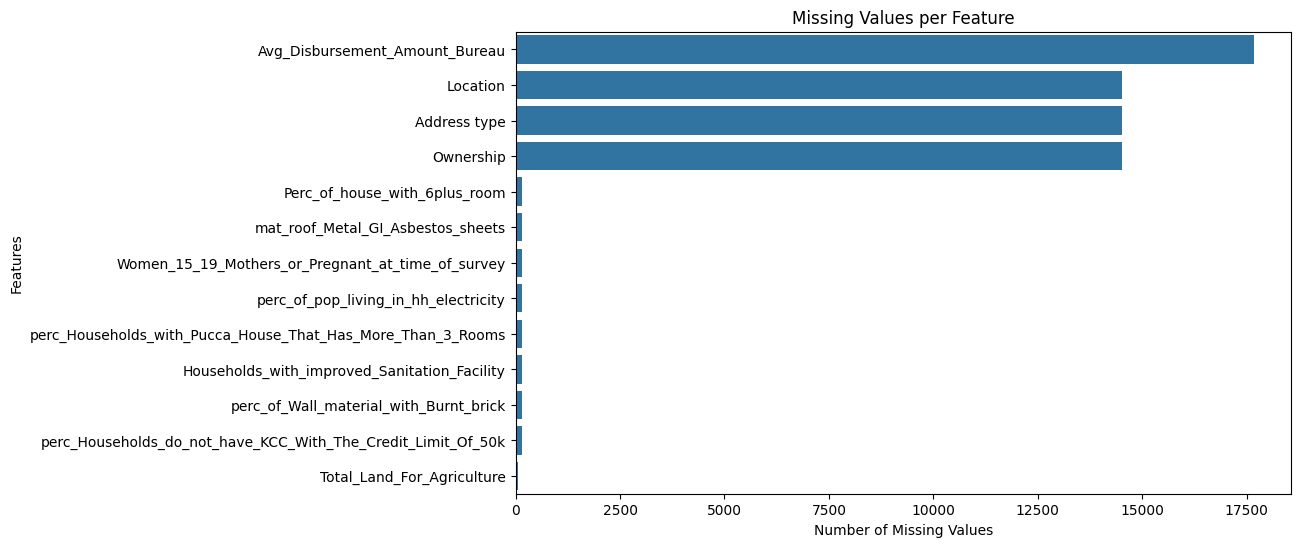

In [ ]:

plt.figure(figsize=(10,6))

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

sns.barplot(x=missing.values, y=missing.index)

plt.title("Missing Values per Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Features")
plt.show()

Correlation with target Variable

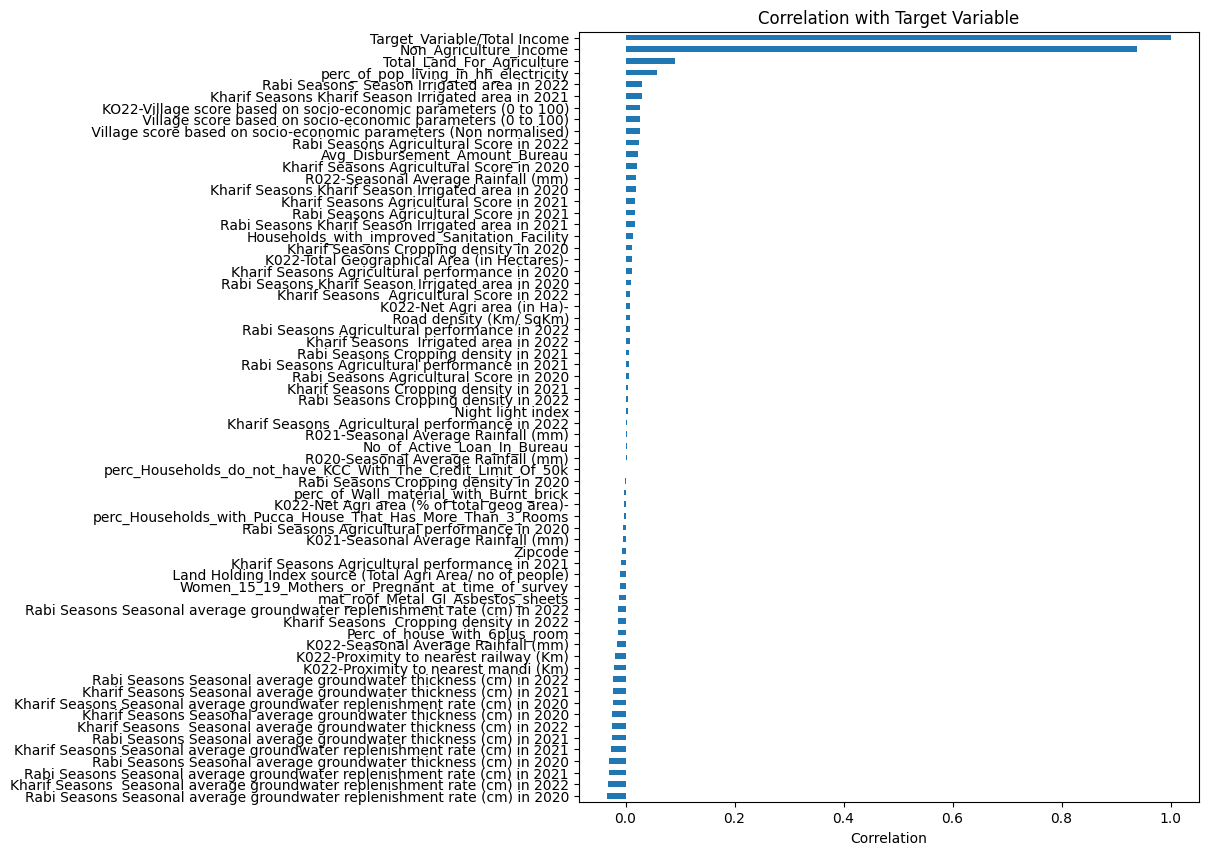

In [ ]:
corr_target = corr["Target_Variable/Total Income"].sort_values()

plt.figure(figsize=(8,10))
corr_target.plot(kind="barh")

plt.title("Correlation with Target Variable")
plt.xlabel("Correlation")
plt.show()

Cardinality Plot to detect columns with high unique values

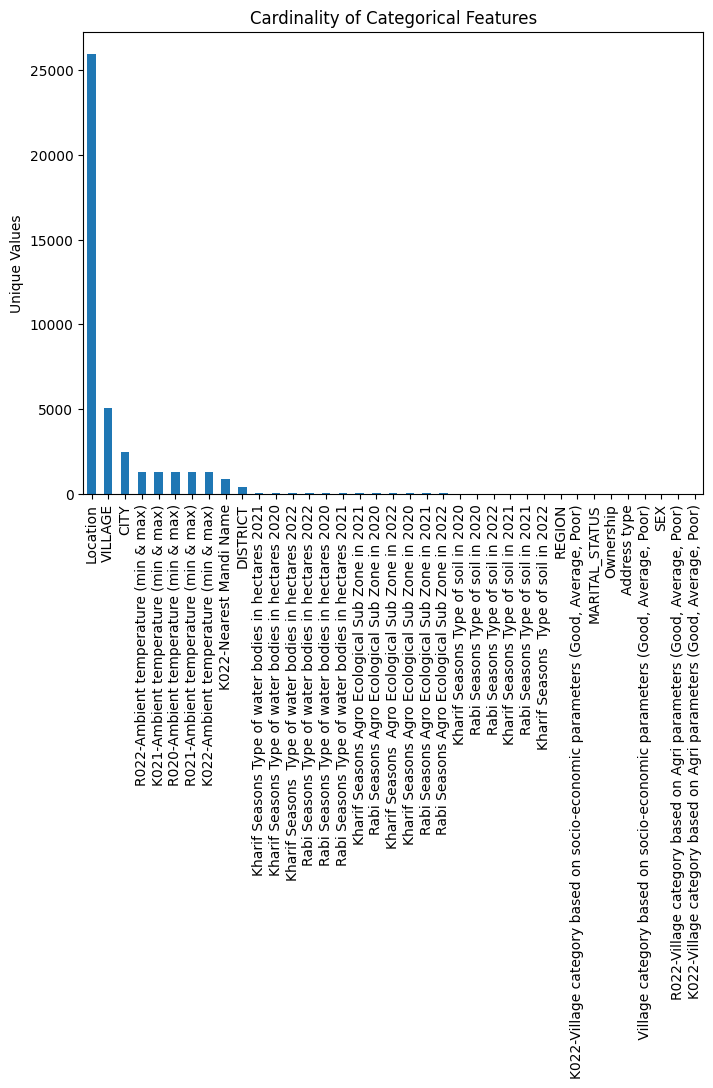

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

cardinality = df[cat_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(8,6))
cardinality.plot(kind="bar")

plt.title("Cardinality of Categorical Features")
plt.ylabel("Unique Values")
plt.show()

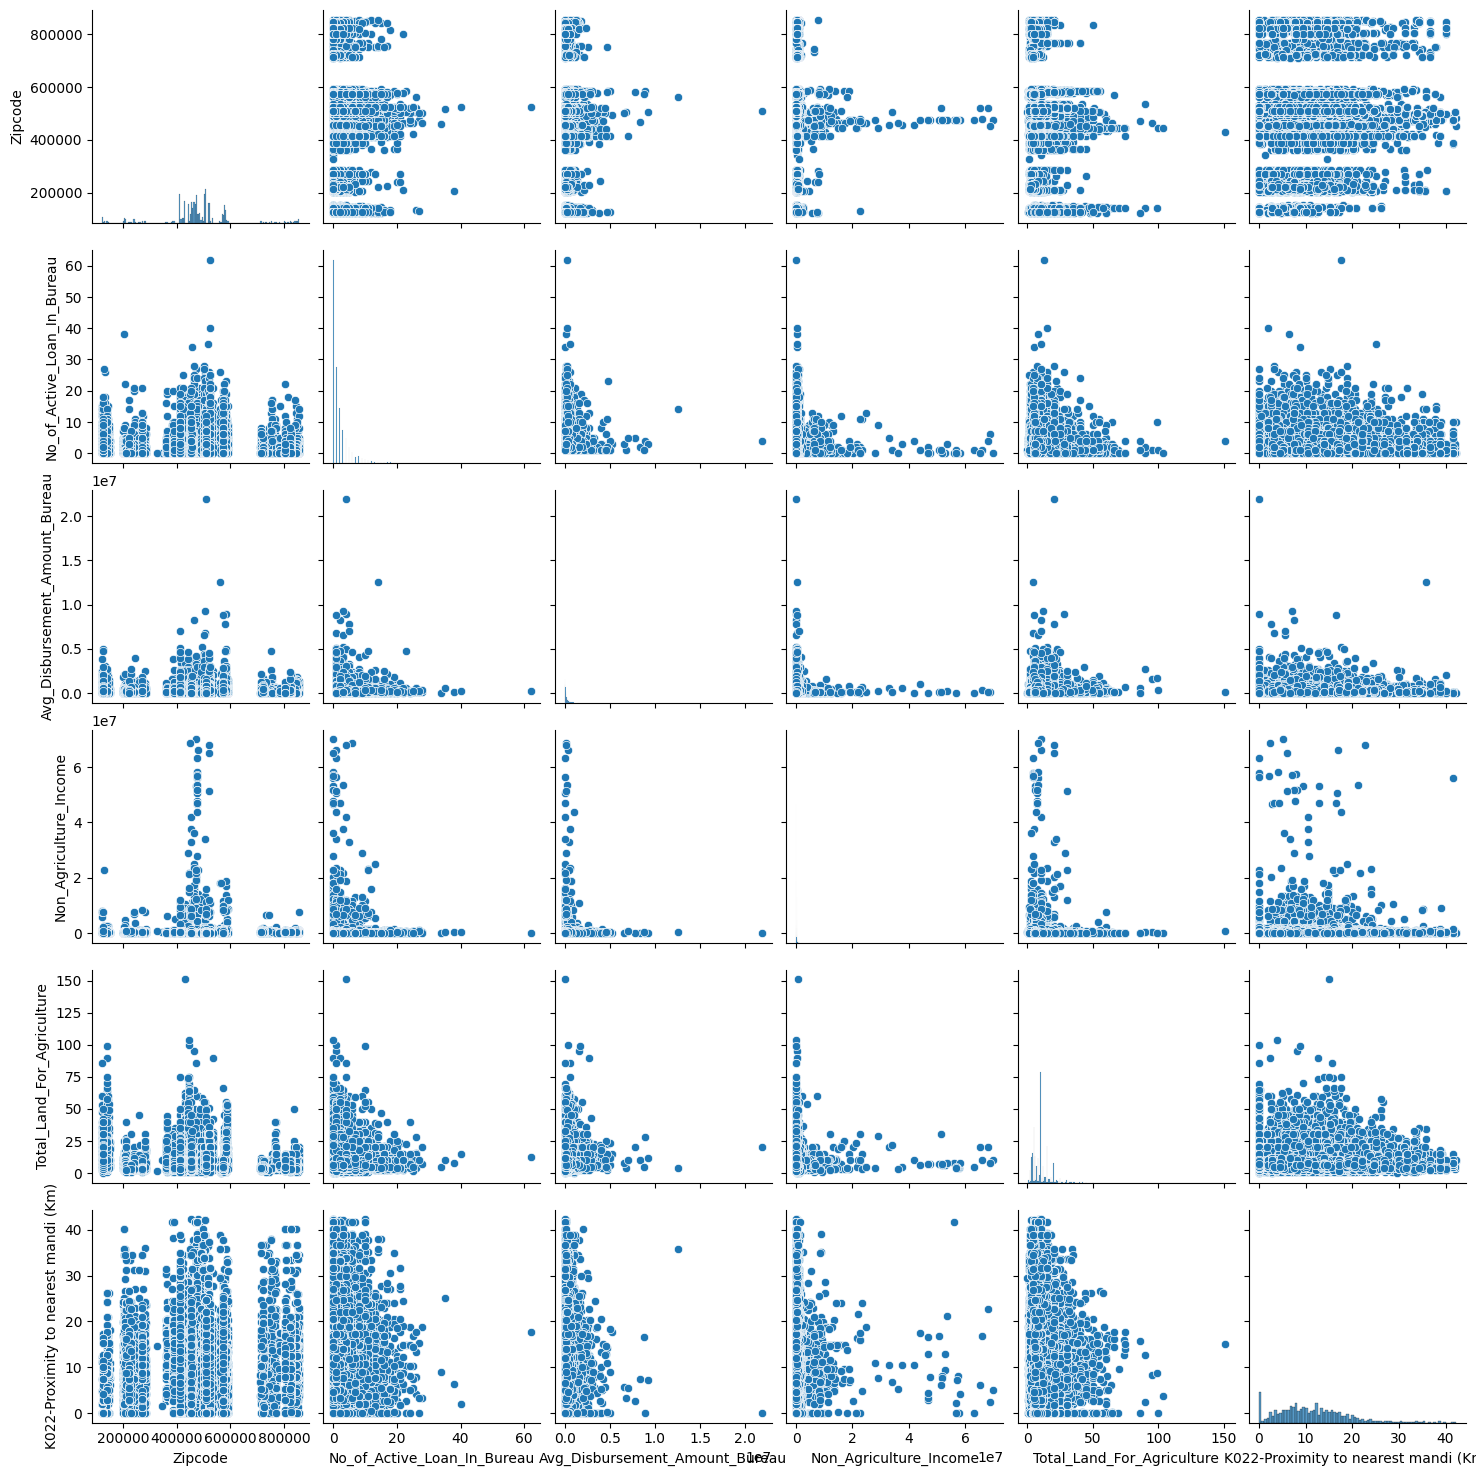

In [ ]:
important_cols = numeric_df.columns[:6]

sns.pairplot(df[important_cols])
plt.show()

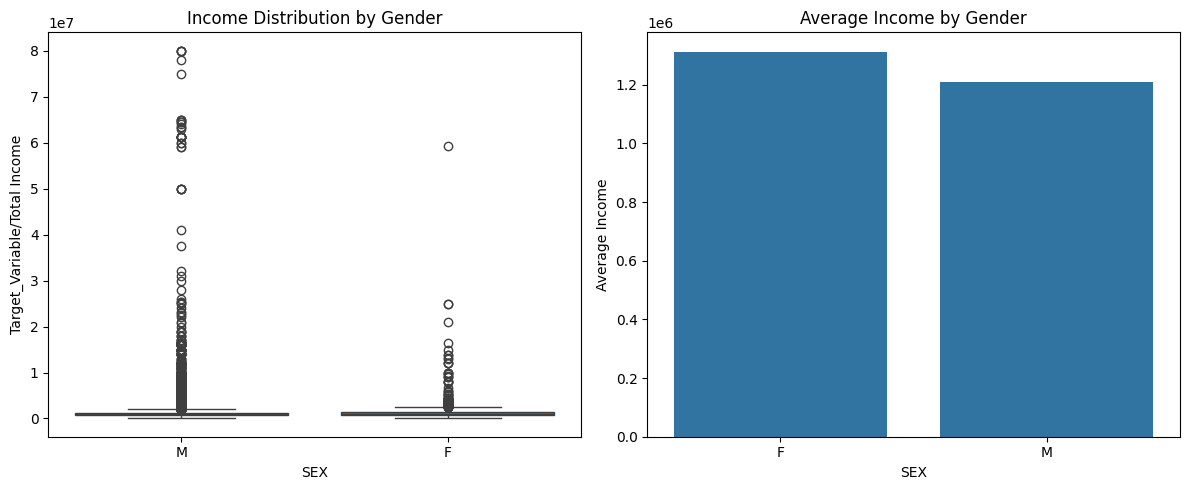

In [ ]:
df.columns = df.columns.str.strip()

target = "Target_Variable/Total Income"

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x="SEX", y=target, data=df)
plt.title("Income Distribution by Gender")

plt.subplot(1,2,2)
avg_income = df.groupby("SEX")[target].mean()

sns.barplot(x=avg_income.index, y=avg_income.values)
plt.title("Average Income by Gender")
plt.xlabel("SEX")
plt.ylabel("Average Income")

plt.tight_layout()
plt.show()



Dropping irrelevant, redundant, and noisy features



* FarmerID : Unique Identifier does not carry any predictive value
* Sex : To not introduce gender bias into the model
* District : Highly location specific and can cause regional bias
* Village: Extremely granular location data; can introduce high cardinality
* Zip Code : Granular Location Data
* MAITIAL_STATUS : Weak correlation with income
* Location : Unique Coordinate Data
* Address Type : Economy based irrelevant feature
* 022-Nearest Mandi Name : high-cardinality categorical feature
* KO22-Village score based on socio-economic parameters (0 to 100) : Similar metric in the final dataset
* Women_15_19_Mothers_or_Pregnant_at_time_of_survey : Irrelevant to individual farmer income prediction
* K022-Total Geographical Area in Hectares : village-level aggregate information
* Night light index : redundant with other socioeconomic indicators
* Ownership : Address non-corelated feature






In [ ]:
cols_to_drop = [
    "FarmerId",
    "SEX",
    "CITY",
    "REGION",
    "DISTRICT",
    "VILLAGE",
    "Zipcode",
    "MARITAL_STATUS",
    "Location",
    "Address type",
    "K022-Nearest Mandi Name",
    "KO22-Village score based on socio-economic parameters (0 to 100)",
    "Women_15_19_Mothers_or_Pregnant_at_time_of_survey",
    "K022-Total Geographical Area (in Hectares)-",
    "Night light index",
    'Kharif Seasons  Type of water bodies in hectares 2022',
    'Rabi Seasons Type of water bodies in hectares 2022',
    'Rabi Seasons Type of water bodies in hectares 2021',
    'Kharif Seasons Type of water bodies in hectares 2021',
    'Kharif Seasons Type of water bodies in hectares 2020',
    'Rabi Seasons Type of water bodies in hectares 2020'
]

train = train.drop(columns=["Ownership"], errors="ignore")
train = train.drop(columns=cols_to_drop, errors="ignore")

test = test.drop(columns=["Ownership"], errors="ignore")
test = test.drop(columns=cols_to_drop, errors="ignore")

df = train.copy()

Checking for missing values

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

Avg_Disbursement_Amount_Bureau                                  17673
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms       157
perc_of_pop_living_in_hh_electricity                              157
Perc_of_house_with_6plus_room                                     157
mat_roof_Metal_GI_Asbestos_sheets                                 157
perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k      157
Households_with_improved_Sanitation_Facility                      157
perc_of_Wall_material_with_Burnt_brick                            157
Total_Land_For_Agriculture                                         61
dtype: int64


0 loan instances are taken as 0 disbursment amount
Converting NaN values in Avg_Disbursement_Amount_Bureau to 0


In [ ]:
train["Avg_Disbursement_Amount_Bureau"] = train["Avg_Disbursement_Amount_Bureau"].fillna(0)
test["Avg_Disbursement_Amount_Bureau"] = test["Avg_Disbursement_Amount_Bureau"].fillna(0)


In [ ]:
print("Train missing:", train["Avg_Disbursement_Amount_Bureau"].isnull().sum())
print("Test missing:", test["Avg_Disbursement_Amount_Bureau"].isnull().sum())

Train missing: 0
Test missing: 0


In [ ]:
train_summary = pd.DataFrame({
    "dtype": train.dtypes,
    "missing": train.isnull().sum(),
    "unique": train.nunique()
})

test_summary = pd.DataFrame({
    "dtype": test.dtypes,
    "missing": test.isnull().sum(),
    "unique": test.nunique()
})

print("TRAIN SUMMARY")
print(train_summary.sort_values("missing", ascending=False).head(20))

print("\nTEST SUMMARY")
print(test_summary.sort_values("missing", ascending=False).head(20))

TRAIN SUMMARY
                                                      dtype  missing  unique
mat_roof_Metal_GI_Asbestos_sheets                   float64      157    2222
perc_Households_with_Pucca_House_That_Has_More_...  float64      157    1407
perc_of_pop_living_in_hh_electricity                float64      157     572
Perc_of_house_with_6plus_room                       float64      157     786
Households_with_improved_Sanitation_Facility        float64      157    1120
perc_Households_do_not_have_KCC_With_The_Credit...  float64      157     903
perc_of_Wall_material_with_Burnt_brick              float64      157    3100
Total_Land_For_Agriculture                          float64       61     372
Non_Agriculture_Income                              float64        0    2649
K022-Seasonal Average Rainfall (mm)                 float64        0    1269
K022-Ambient temperature (min & max)                 object        0    1253
R022-Village category based on Agri parameters ...   object   

## FEATURE ENGINEERING

Merging and Creating Mean Columns of yearwise rainfall and temperature data

In [ ]:
train["Kharif_seasonal_average_rainfall"] = train[
    ["K022-Seasonal Average Rainfall (mm)", "K021-Seasonal Average Rainfall (mm)"]
].mean(axis=1)

test["Kharif_seasonal_average_rainfall"] = test[
    ["K022-Seasonal Average Rainfall (mm)", "K021-Seasonal Average Rainfall (mm)"]
].mean(axis=1)

train = train.drop(columns=[
    "K022-Seasonal Average Rainfall (mm)",
    "K021-Seasonal Average Rainfall (mm)"
], errors="ignore")

test = test.drop(columns=[
    "K022-Seasonal Average Rainfall (mm)",
    "K021-Seasonal Average Rainfall (mm)"
], errors="ignore")

train["Rabi_seasonal_average_rainfall"] = train[
    [
        "R022-Seasonal Average Rainfall (mm)",
        "R021-Seasonal Average Rainfall (mm)",
        "R020-Seasonal Average Rainfall (mm)"
    ]
].mean(axis=1)

test["Rabi_seasonal_average_rainfall"] = test[
    [
        "R022-Seasonal Average Rainfall (mm)",
        "R021-Seasonal Average Rainfall (mm)",
        "R020-Seasonal Average Rainfall (mm)"
    ]
].mean(axis=1)

train = train.drop(columns=[
    "R022-Seasonal Average Rainfall (mm)",
    "R021-Seasonal Average Rainfall (mm)",
    "R020-Seasonal Average Rainfall (mm)"
], errors="ignore")

test = test.drop(columns=[
    "R022-Seasonal Average Rainfall (mm)",
    "R021-Seasonal Average Rainfall (mm)",
    "R020-Seasonal Average Rainfall (mm)"
], errors="ignore")



In [ ]:
train["Kharif_seasonal_average_temperature"] = (
    train[["K022-Ambient temperature (min & max)", "K021-Ambient temperature (min & max)"]]
    .apply(lambda s: (
        s.str.replace(" ", "", regex=False)
         .str.split("/", expand=True)
         .astype(float)
         .mean(axis=1)
    ))
    .mean(axis=1)
)

test["Kharif_seasonal_average_temperature"] = (
    test[["K022-Ambient temperature (min & max)", "K021-Ambient temperature (min & max)"]]
    .apply(lambda s: (
        s.str.replace(" ", "", regex=False)
         .str.split("/", expand=True)
         .astype(float)
         .mean(axis=1)
    ))
    .mean(axis=1)
)

train = train.drop(columns=[
    "K022-Ambient temperature (min & max)",
    "K021-Ambient temperature (min & max)"
], errors="ignore")

test = test.drop(columns=[
    "K022-Ambient temperature (min & max)",
    "K021-Ambient temperature (min & max)"
], errors="ignore")

train["Rabi_seasonal_average_temperature"] = (
    train[
        [
            "R022-Ambient temperature (min & max)",
            "R021-Ambient temperature (min & max)",
            "R020-Ambient temperature (min & max)"
        ]
    ]
    .apply(lambda s: (
        s.str.replace(" ", "", regex=False)
         .str.split("/", expand=True)
         .astype(float)
         .mean(axis=1)
    ))
    .mean(axis=1)
)

test["Rabi_seasonal_average_temperature"] = (
    test[
        [
            "R022-Ambient temperature (min & max)",
            "R021-Ambient temperature (min & max)",
            "R020-Ambient temperature (min & max)"
        ]
    ]
    .apply(lambda s: (
        s.str.replace(" ", "", regex=False)
         .str.split("/", expand=True)
         .astype(float)
         .mean(axis=1)
    ))
    .mean(axis=1)
)

train = train.drop(columns=[
    "R022-Ambient temperature (min & max)",
    "R021-Ambient temperature (min & max)",
    "R020-Ambient temperature (min & max)"
], errors="ignore")

test = test.drop(columns=[
    "R022-Ambient temperature (min & max)",
    "R021-Ambient temperature (min & max)",
    "R020-Ambient temperature (min & max)"
], errors="ignore")



Creating a new mean feature of sub zones

In [ ]:
(train["Rabi Seasons Agro Ecological Sub Zone in 2021"] ==
 train["Rabi Seasons Agro Ecological Sub Zone in 2020"]).mean()

(train["Rabi Seasons Agro Ecological Sub Zone in 2022"] ==
 train["Rabi Seasons Agro Ecological Sub Zone in 2020"]).mean()

train = train.drop(columns=[
    "Rabi Seasons Agro Ecological Sub Zone in 2021",
    "Rabi Seasons Agro Ecological Sub Zone in 2020"
], errors="ignore")

train = train.rename(columns={
    "Rabi Seasons Agro Ecological Sub Zone in 2022": "Rabi_Agro_Eco_Zone"
})


test = test.drop(columns=[
    "Rabi Seasons Agro Ecological Sub Zone in 2021",
    "Rabi Seasons Agro Ecological Sub Zone in 2020"
], errors="ignore")

test = test.rename(columns={
    "Rabi Seasons Agro Ecological Sub Zone in 2022": "Rabi_Agro_Eco_Zone"
})



Creating new numerical features by basic operations

In [ ]:
train["Market_Accessibility"] = (
    train["K022-Proximity to nearest mandi (Km)"] *
    train["K022-Proximity to nearest railway (Km)"]
)

test["Market_Accessibility"] = (
    test["K022-Proximity to nearest mandi (Km)"] *
    test["K022-Proximity to nearest railway (Km)"]
)

train = train.drop(columns=[
    "K022-Proximity to nearest mandi (Km)",
    "K022-Proximity to nearest railway (Km)"
], errors="ignore")

test = test.drop(columns=[
    "K022-Proximity to nearest mandi (Km)",
    "K022-Proximity to nearest railway (Km)"
], errors="ignore")


train["Total_disbursement"] = (
    train["Avg_Disbursement_Amount_Bureau"] *
    train["No_of_Active_Loan_In_Bureau"]
)

test["Total_disbursement"] = (
    test["Avg_Disbursement_Amount_Bureau"] *
    test["No_of_Active_Loan_In_Bureau"]
)

train = train.drop(columns=[
    "Avg_Disbursement_Amount_Bureau",
    "No_of_Active_Loan_In_Bureau"
], errors="ignore")

test = test.drop(columns=[
    "Avg_Disbursement_Amount_Bureau",
    "No_of_Active_Loan_In_Bureau"
], errors="ignore")


Slicing eco_zone feature for climate information

In [ ]:
train["Rabi_Climate_Type"] = (
    train["Rabi_Agro_Eco_Zone"]
    .str.upper()
    .str.extract(r"(HOT\s+SUBHUMID|SUBHUMID|HOT\s+SEMI[- ]?ARID|SEMI[- ]?ARID)", expand=False)
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

test["Rabi_Climate_Type"] = (
    test["Rabi_Agro_Eco_Zone"]
    .str.upper()
    .str.extract(r"(HOT\s+SUBHUMID|SUBHUMID|HOT\s+SEMI[- ]?ARID|SEMI[- ]?ARID)", expand=False)
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

train = train.drop(columns=["Rabi_Agro_Eco_Zone"], errors="ignore")
test = test.drop(columns=["Rabi_Agro_Eco_Zone"], errors="ignore")

train["Rabi_Climate_Type"] = train["Rabi_Climate_Type"].fillna("UNKNOWN")
test["Rabi_Climate_Type"] = test["Rabi_Climate_Type"].fillna("UNKNOWN")


train["Kharif_Agro_Eco_Zone"] = train[
    [
        "Kharif Seasons  Agro Ecological Sub Zone in 2022",
        "Kharif Seasons Agro Ecological Sub Zone in 2021",
        "Kharif Seasons Agro Ecological Sub Zone in 2020"
    ]
].mode(axis=1)[0]

test["Kharif_Agro_Eco_Zone"] = test[
    [
        "Kharif Seasons  Agro Ecological Sub Zone in 2022",
        "Kharif Seasons Agro Ecological Sub Zone in 2021",
        "Kharif Seasons Agro Ecological Sub Zone in 2020"
    ]
].mode(axis=1)[0]

train["Kharif_Climate_Type"] = (
    train["Kharif_Agro_Eco_Zone"]
    .str.upper()
    .str.extract(r"(HOT\s+SUBHUMID|SUBHUMID|HOT\s+SEMI[- ]?ARID|SEMI[- ]?ARID)", expand=False)
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

test["Kharif_Climate_Type"] = (
    test["Kharif_Agro_Eco_Zone"]
    .str.upper()
    .str.extract(r"(HOT\s+SUBHUMID|SUBHUMID|HOT\s+SEMI[- ]?ARID|SEMI[- ]?ARID)", expand=False)
    .str.replace(" ", "_")
    .str.replace("-", "_")
)


train = train.drop(columns=[
    "Kharif Seasons  Agro Ecological Sub Zone in 2022",
    "Kharif Seasons Agro Ecological Sub Zone in 2021",
    "Kharif Seasons Agro Ecological Sub Zone in 2020",
    "Kharif_Agro_Eco_Zone"
], errors="ignore")

test = test.drop(columns=[
    "Kharif Seasons  Agro Ecological Sub Zone in 2022",
    "Kharif Seasons Agro Ecological Sub Zone in 2021",
    "Kharif Seasons Agro Ecological Sub Zone in 2020",
    "Kharif_Agro_Eco_Zone"
], errors="ignore")


train["Kharif_Climate_Type"] = train["Kharif_Climate_Type"].fillna("UNKNOWN")
test["Kharif_Climate_Type"] = test["Kharif_Climate_Type"].fillna("UNKNOWN")



Creating Soil Type Feature across yearwise data

In [ ]:
(train["Kharif Seasons  Type of soil in 2022"]
 == train["Kharif Seasons Type of soil in 2021"]).mean()
(train["Kharif Seasons Type of soil in 2021"]
 == train["Kharif Seasons Type of soil in 2020"]).mean()
(train["Kharif Seasons  Type of soil in 2022"]
 == train["Kharif Seasons Type of soil in 2020"]).mean()

np.float64(0.9145043410016187)

In [ ]:
train["Kharif_Soil_Type"] = train[
    [
        "Kharif Seasons  Type of soil in 2022",
        "Kharif Seasons Type of soil in 2021",
        "Kharif Seasons Type of soil in 2020"
    ]
].mode(axis=1)[0]

test["Kharif_Soil_Type"] = test[
    [
        "Kharif Seasons  Type of soil in 2022",
        "Kharif Seasons Type of soil in 2021",
        "Kharif Seasons Type of soil in 2020"
    ]
].mode(axis=1)[0]


train = train.drop(columns=[
    "Kharif Seasons  Type of soil in 2022",
    "Kharif Seasons Type of soil in 2021",
    "Kharif Seasons Type of soil in 2020"
], errors="ignore")

test = test.drop(columns=[
    "Kharif Seasons  Type of soil in 2022",
    "Kharif Seasons Type of soil in 2021",
    "Kharif Seasons Type of soil in 2020"
], errors="ignore")



In [ ]:
train["Rabi_Soil_Type"] = train[
    [
        "Rabi Seasons Type of soil in 2022",
        "Rabi Seasons Type of soil in 2021",
        "Rabi Seasons Type of soil in 2020"
    ]
].mode(axis=1)[0]

test["Rabi_Soil_Type"] = test[
    [
        "Rabi Seasons Type of soil in 2022",
        "Rabi Seasons Type of soil in 2021",
        "Rabi Seasons Type of soil in 2020"
    ]
].mode(axis=1)[0]


train = train.drop(columns=[
    "Rabi Seasons Type of soil in 2022",
    "Rabi Seasons Type of soil in 2021",
    "Rabi Seasons Type of soil in 2020"
], errors="ignore")

test = test.drop(columns=[
    "Rabi Seasons Type of soil in 2022",
    "Rabi Seasons Type of soil in 2021",
    "Rabi Seasons Type of soil in 2020"
], errors="ignore")

Mean of irrigated area feature

In [ ]:
train["Kharif_avg_irrigated_area"] = train[
    [
        "Kharif Seasons  Irrigated area in 2022",
        "Kharif Seasons Kharif Season Irrigated area in 2021",
        "Kharif Seasons Kharif Season Irrigated area in 2020"
    ]
].mean(axis=1)

test["Kharif_avg_irrigated_area"] = test[
    [
        "Kharif Seasons  Irrigated area in 2022",
        "Kharif Seasons Kharif Season Irrigated area in 2021",
        "Kharif Seasons Kharif Season Irrigated area in 2020"
    ]
].mean(axis=1)


train = train.drop(columns=[
    "Kharif Seasons  Irrigated area in 2022",
    "Kharif Seasons Kharif Season Irrigated area in 2021",
    "Kharif Seasons Kharif Season Irrigated area in 2020"
], errors="ignore")

test = test.drop(columns=[
    "Kharif Seasons  Irrigated area in 2022",
    "Kharif Seasons Kharif Season Irrigated area in 2021",
    "Kharif Seasons Kharif Season Irrigated area in 2020"
], errors="ignore")


train["Kharif_avg_irrigated_area"].head()

,Kharif_avg_irrigated_area
0,65.253333
1,17.726667
2,77.356667
3,71.260000
4,67.430000


In [ ]:
train["Rabi_avg_irrigated_area"] = train[
    [
        "Rabi Seasons  Season Irrigated area in 2022",
        "Rabi Seasons Kharif Season Irrigated area in 2021",
        "Rabi Seasons Kharif Season Irrigated area in 2020"
    ]
].mean(axis=1)

test["Rabi_avg_irrigated_area"] = test[
    [
        "Rabi Seasons  Season Irrigated area in 2022",
        "Rabi Seasons Kharif Season Irrigated area in 2021",
        "Rabi Seasons Kharif Season Irrigated area in 2020"
    ]
].mean(axis=1)


train = train.drop(columns=[
    "Rabi Seasons  Season Irrigated area in 2022",
    "Rabi Seasons Kharif Season Irrigated area in 2021",
    "Rabi Seasons Kharif Season Irrigated area in 2020"
], errors="ignore")

test = test.drop(columns=[
    "Rabi Seasons  Season Irrigated area in 2022",
    "Rabi Seasons Kharif Season Irrigated area in 2021",
    "Rabi Seasons Kharif Season Irrigated area in 2020"
], errors="ignore")

train["Rabi_avg_irrigated_area"].head()

,Rabi_avg_irrigated_area
0,60.193333
1,2.220000
2,75.800000
3,77.466667
4,81.010000


Mean of yearwise Data feature (merging)

In [ ]:
train["Kharif_avg_cropping_density"] = train[
    [
        "Kharif Seasons  Cropping density in 2022",
        "Kharif Seasons Cropping density in 2021",
        "Kharif Seasons Cropping density in 2020"
    ]
].mean(axis=1)

test["Kharif_avg_cropping_density"] = test[
    [
        "Kharif Seasons  Cropping density in 2022",
        "Kharif Seasons Cropping density in 2021",
        "Kharif Seasons Cropping density in 2020"
    ]
].mean(axis=1)


train["Kharif_avg_agricultural_performance"] = train[
    [
        "Kharif Seasons  Agricultural performance in 2022",
        "Kharif Seasons Agricultural performance in 2021",
        "Kharif Seasons Agricultural performance in 2020"
    ]
].mean(axis=1)

test["Kharif_avg_agricultural_performance"] = test[
    [
        "Kharif Seasons  Agricultural performance in 2022",
        "Kharif Seasons Agricultural performance in 2021",
        "Kharif Seasons Agricultural performance in 2020"
    ]
].mean(axis=1)


train["Kharif_avg_agricultural_score"] = train[
    [
        "Kharif Seasons  Agricultural Score in 2022",
        "Kharif Seasons Agricultural Score in 2021",
        "Kharif Seasons Agricultural Score in 2020"
    ]
].mean(axis=1)

test["Kharif_avg_agricultural_score"] = test[
    [
        "Kharif Seasons  Agricultural Score in 2022",
        "Kharif Seasons Agricultural Score in 2021",
        "Kharif Seasons Agricultural Score in 2020"
    ]
].mean(axis=1)


train["Kharif_avg_groundwater_thickness"] = train[
    [
        "Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022",
        "Kharif Seasons Seasonal average groundwater thickness (cm) in 2021",
        "Kharif Seasons Seasonal average groundwater thickness (cm) in 2020"
    ]
].mean(axis=1)

test["Kharif_avg_groundwater_thickness"] = test[
    [
        "Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022",
        "Kharif Seasons Seasonal average groundwater thickness (cm) in 2021",
        "Kharif Seasons Seasonal average groundwater thickness (cm) in 2020"
    ]
].mean(axis=1)

train["Kharif_avg_groundwater_replenishment"] = train[
    [
        "Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022",
        "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
        "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020"
    ]
].mean(axis=1)

test["Kharif_avg_groundwater_replenishment"] = test[
    [
        "Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022",
        "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
        "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020"
    ]
].mean(axis=1)

cols_to_drop = [
    "Kharif Seasons  Cropping density in 2022",
    "Kharif Seasons Cropping density in 2021",
    "Kharif Seasons Cropping density in 2020",

    "Kharif Seasons  Agricultural performance in 2022",
    "Kharif Seasons Agricultural performance in 2021",
    "Kharif Seasons Agricultural performance in 2020",

    "Kharif Seasons  Agricultural Score in 2022",
    "Kharif Seasons Agricultural Score in 2021",
    "Kharif Seasons Agricultural Score in 2020",

    "Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022",
    "Kharif Seasons Seasonal average groundwater thickness (cm) in 2021",
    "Kharif Seasons Seasonal average groundwater thickness (cm) in 2020",

    "Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022",
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020"
]

train = train.drop(columns=cols_to_drop, errors="ignore")
test = test.drop(columns=cols_to_drop, errors="ignore")

In [ ]:
train["Rabi_avg_cropping_density"] = train[
    [
        "Rabi Seasons Cropping density in 2022",
        "Rabi Seasons Cropping density in 2021",
        "Rabi Seasons Cropping density in 2020"
    ]
].mean(axis=1)

test["Rabi_avg_cropping_density"] = test[
    [
        "Rabi Seasons Cropping density in 2022",
        "Rabi Seasons Cropping density in 2021",
        "Rabi Seasons Cropping density in 2020"
    ]
].mean(axis=1)

train["Rabi_avg_agricultural_performance"] = train[
    [
        "Rabi Seasons Agricultural performance in 2022",
        "Rabi Seasons Agricultural performance in 2021",
        "Rabi Seasons Agricultural performance in 2020"
    ]
].mean(axis=1)

test["Rabi_avg_agricultural_performance"] = test[
    [
        "Rabi Seasons Agricultural performance in 2022",
        "Rabi Seasons Agricultural performance in 2021",
        "Rabi Seasons Agricultural performance in 2020"
    ]
].mean(axis=1)

train["Rabi_avg_agricultural_score"] = train[
    [
        "Rabi Seasons Agricultural Score in 2022",
        "Rabi Seasons Agricultural Score in 2021",
        "Rabi Seasons Agricultural Score in 2020"
    ]
].mean(axis=1)

test["Rabi_avg_agricultural_score"] = test[
    [
        "Rabi Seasons Agricultural Score in 2022",
        "Rabi Seasons Agricultural Score in 2021",
        "Rabi Seasons Agricultural Score in 2020"
    ]
].mean(axis=1)

train["Rabi_avg_groundwater_thickness"] = train[
    [
        "Rabi Seasons Seasonal average groundwater thickness (cm) in 2022",
        "Rabi Seasons Seasonal average groundwater thickness (cm) in 2021",
        "Rabi Seasons Seasonal average groundwater thickness (cm) in 2020"
    ]
].mean(axis=1)

test["Rabi_avg_groundwater_thickness"] = test[
    [
        "Rabi Seasons Seasonal average groundwater thickness (cm) in 2022",
        "Rabi Seasons Seasonal average groundwater thickness (cm) in 2021",
        "Rabi Seasons Seasonal average groundwater thickness (cm) in 2020"
    ]
].mean(axis=1)

train["Rabi_avg_groundwater_replenishment"] = train[
    [
        "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022",
        "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
        "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020"
    ]
].mean(axis=1)

test["Rabi_avg_groundwater_replenishment"] = test[
    [
        "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022",
        "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
        "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020"
    ]
].mean(axis=1)

cols_to_drop = [

    "Rabi Seasons Cropping density in 2022",
    "Rabi Seasons Cropping density in 2021",
    "Rabi Seasons Cropping density in 2020",

    "Rabi Seasons Agricultural performance in 2022",
    "Rabi Seasons Agricultural performance in 2021",
    "Rabi Seasons Agricultural performance in 2020",

    "Rabi Seasons Agricultural Score in 2022",
    "Rabi Seasons Agricultural Score in 2021",
    "Rabi Seasons Agricultural Score in 2020",

    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2022",
    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2021",
    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2020",

    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020"
]

train = train.drop(columns=cols_to_drop, errors="ignore")
test = test.drop(columns=cols_to_drop, errors="ignore")

In [ ]:
train.head()

,State,Non_Agriculture_Income,Total_Land_For_Agriculture,"K022-Village category based on Agri parameters (Good, Average, Poor)","K022-Village category based on socio-economic parameters (Good, Average, Poor)","R022-Village category based on Agri parameters (Good, Average, Poor)",Perc_of_house_with_6plus_room,perc_of_pop_living_in_hh_electricity,perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,mat_roof_Metal_GI_Asbestos_sheets,...,Kharif_avg_cropping_density,Kharif_avg_agricultural_performance,Kharif_avg_agricultural_score,Kharif_avg_groundwater_thickness,Kharif_avg_groundwater_replenishment,Rabi_avg_cropping_density,Rabi_avg_agricultural_performance,Rabi_avg_agricultural_score,Rabi_avg_groundwater_thickness,Rabi_avg_groundwater_replenishment
0,MADHYA PRADESH,100000.0,10.0,Poor,Poor,Poor,1.23,99.30,2.22,0.74,...,71.120000,15.993333,23.303333,97.403333,25.276667,61.976667,25.040000,25.046667,93.803333,17.213333
1,BIHAR,500000.0,6.0,Poor,Poor,Poor,1.41,95.85,3.77,7.98,...,9.586667,19.723333,15.793333,78.600000,25.096667,6.833333,20.230000,12.860000,77.936667,19.670000
2,MADHYA PRADESH,492500.0,5.0,Average,Poor,Average,0.77,99.90,3.04,8.51,...,76.563333,29.330000,32.960000,86.856667,18.323333,75.743333,38.316667,37.746667,87.900000,16.403333
3,MAHARASHTRA,40000.0,5.3,Average,Average,Average,1.28,97.12,9.71,76.31,...,90.633333,21.083333,35.013333,101.403333,29.506667,87.920000,25.880000,40.166667,96.516667,22.716667
4,MADHYA PRADESH,150000.0,10.0,Poor,Poor,Poor,2.92,98.60,3.26,1.65,...,64.256667,14.260000,22.576667,94.950000,22.403333,58.800000,21.566667,29.296667,92.586667,16.093333


Rechecking the Correlation Matrix

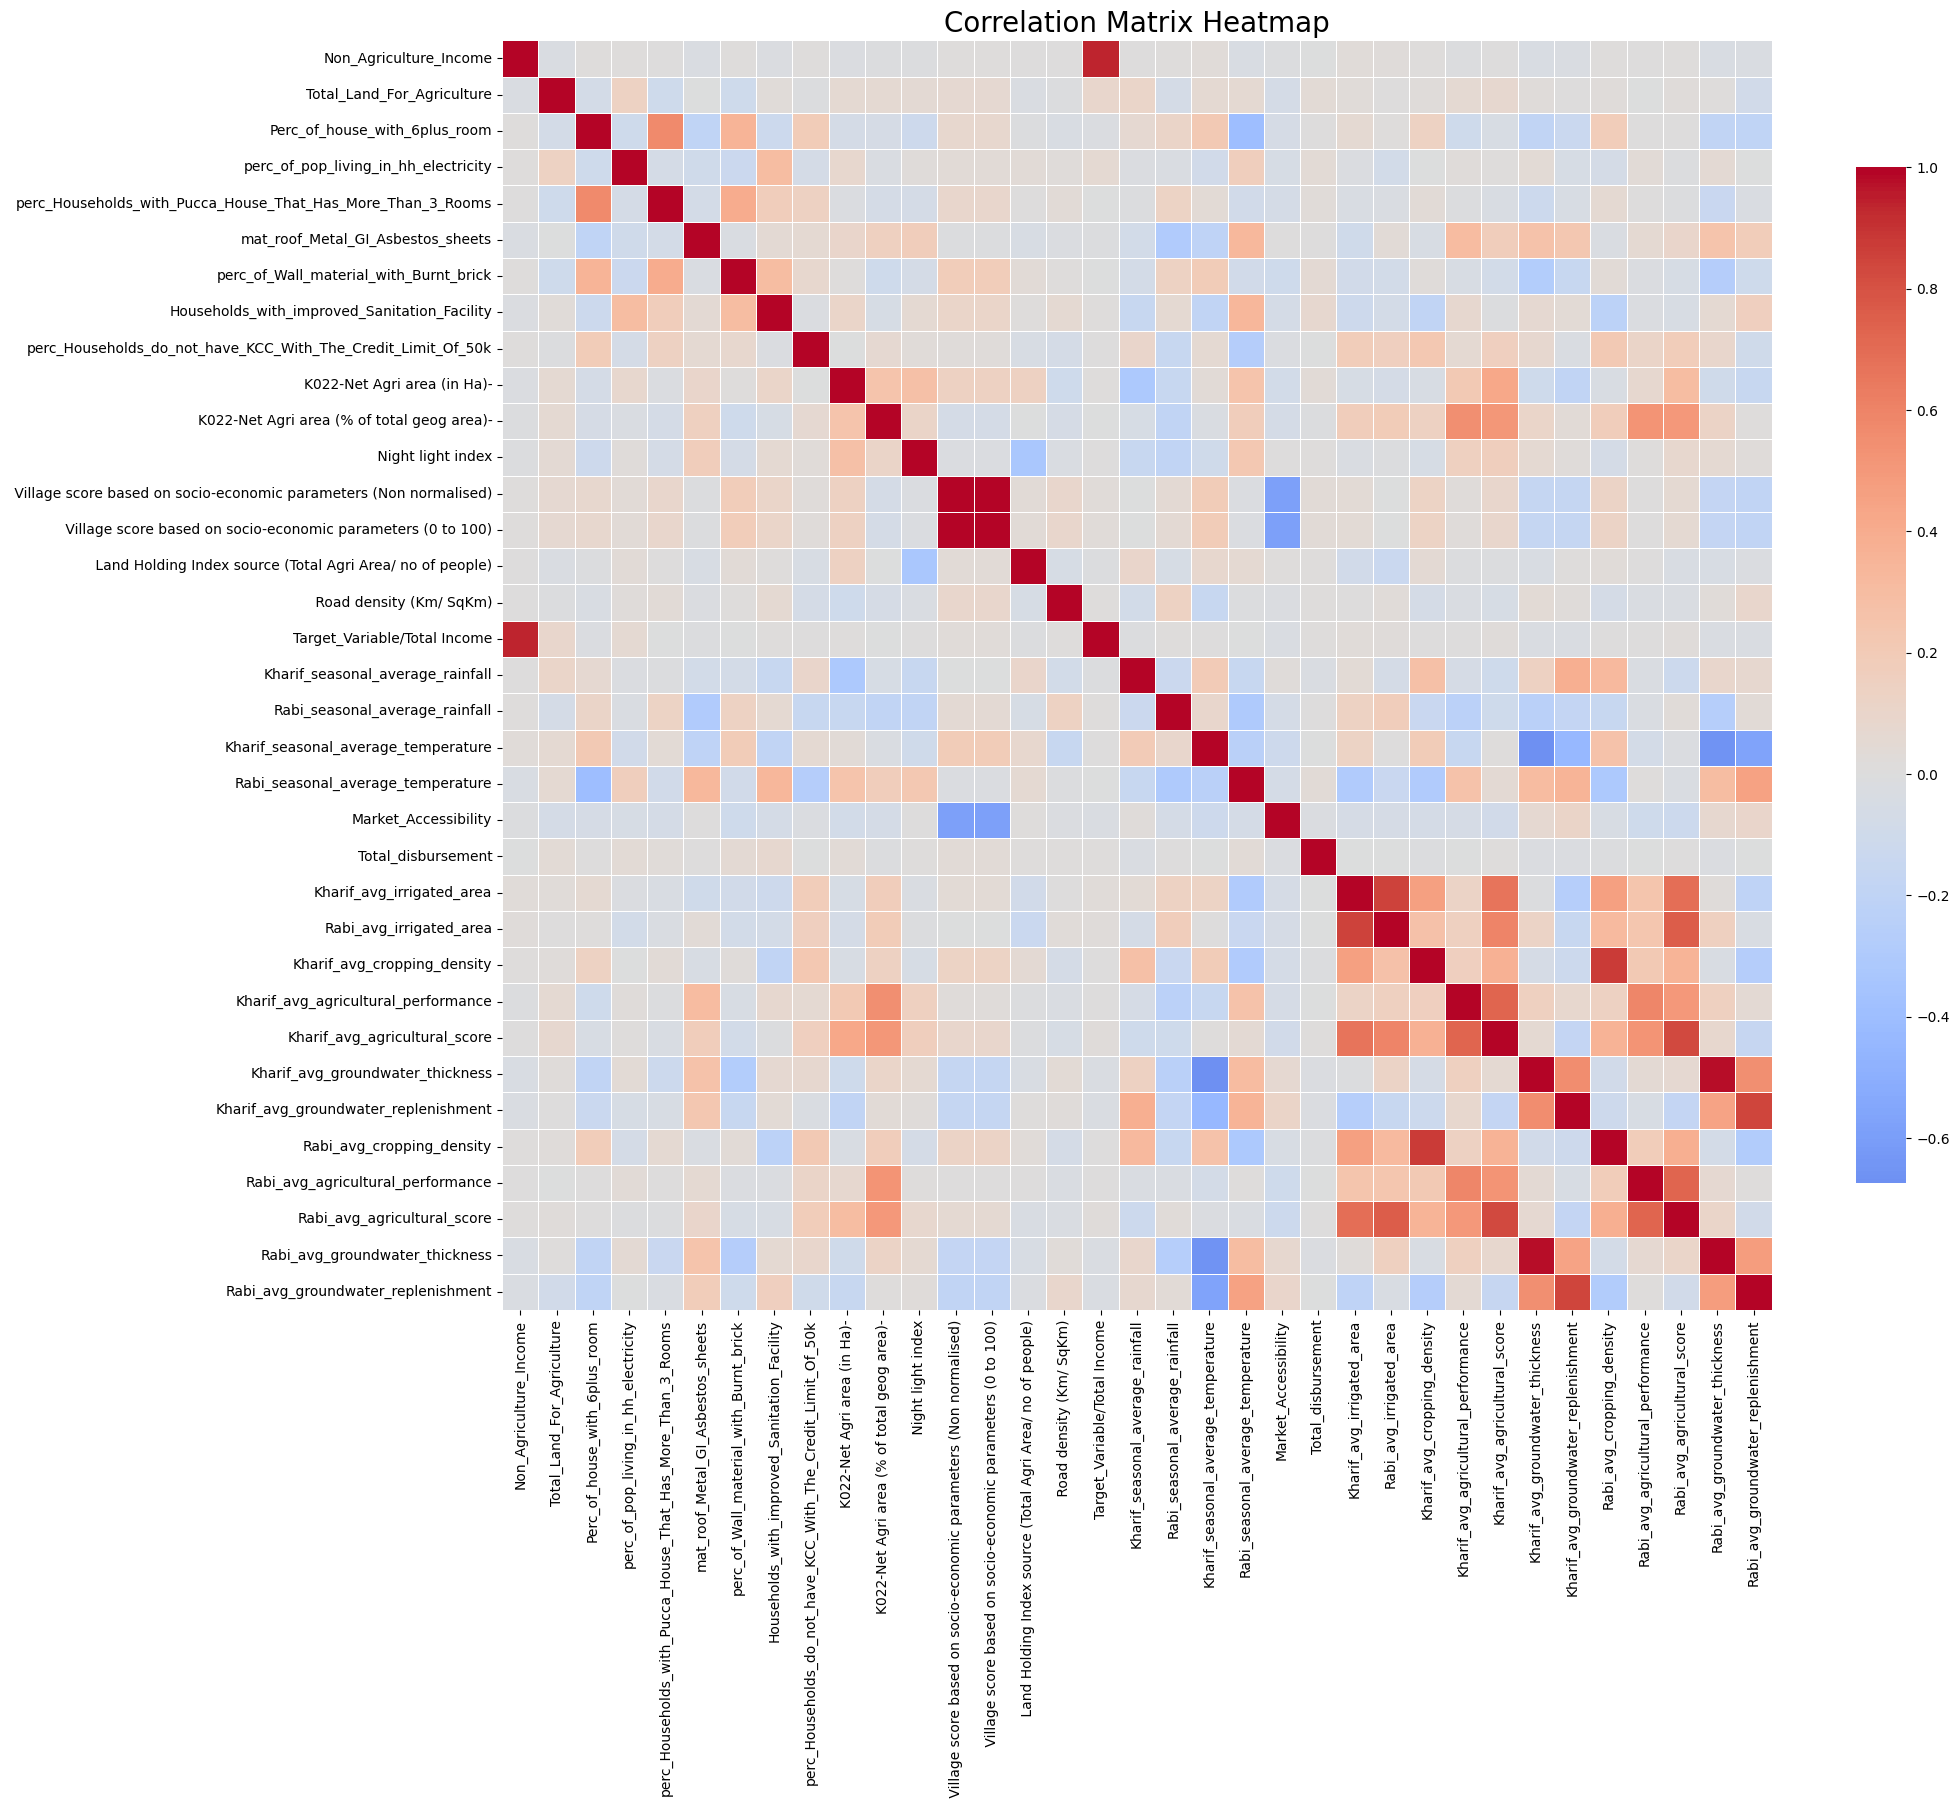

In [ ]:
train_corr_df = train.iloc[:, 1:]

numeric_df = train_corr_df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(22, 18))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Heatmap", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## ENCODING

Encoding states

In [ ]:
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['State',
       'K022-Village category based on Agri parameters (Good, Average, Poor)',
       'K022-Village category based on socio-economic parameters (Good, Average, Poor)',
       'R022-Village category based on Agri parameters (Good, Average, Poor)',
       ' Village category based on socio-economic parameters (Good, Average, Poor)',
       'Rabi_Climate_Type', 'Kharif_Climate_Type', 'Kharif_Soil_Type',
       'Rabi_Soil_Type'],
      dtype='object')


In [ ]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train["State"] = train["State"].fillna("Unknown")
test["State"] = test["State"].fillna("Unknown")

train = pd.get_dummies(train, columns=["State"], prefix="State", drop_first=True)
test = pd.get_dummies(test, columns=["State"], prefix="State", drop_first=True)

state_cols = [col for col in train.columns if col.startswith("State_")]
train[state_cols] = train[state_cols].astype(int)

test_cols = [col for col in test.columns if col.startswith("State_")]
test[test_cols] = test[test_cols].astype(int)
print("New One-Hot Encoded State Columns:")
print(state_cols)
print("\nSample Output:")
print(train[state_cols].head())

New One-Hot Encoded State Columns:
['State_ASSAM', 'State_BIHAR', 'State_CHANDIGARH', 'State_CHATTISGARH', 'State_GUJARAT', 'State_HARYANA', 'State_JHARKHAND', 'State_KARNATAKA', 'State_MADHYA PRADESH', 'State_MAHARASHTRA', 'State_ODISHA', 'State_PUNJAB', 'State_RAJASTHAN', 'State_TELANGANA', 'State_UTTAR PRADESH', 'State_WEST BENGAL']

Sample Output:
   State_ASSAM  State_BIHAR  State_CHANDIGARH  State_CHATTISGARH  \
0            0            0                 0                  0   
1            0            1                 0                  0   
2            0            0                 0                  0   
3            0            0                 0                  0   
4            0            0                 0                  0   

   State_GUJARAT  State_HARYANA  State_JHARKHAND  State_KARNATAKA  \
0              0              0                0                0   
1              0              0                0                0   
2              0              

In [ ]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()


if "State" in train.columns:
    train.drop(columns=["State"], inplace=True)

if "State" in test.columns:
    test.drop(columns=["State"], inplace=True)

state_cols = [col for col in train.columns if col.startswith("State_")]

print("Remaining encoded state columns:")
print(state_cols)

print("\nPreview:")
print(train[state_cols].head())

Remaining encoded state columns:
['State_ASSAM', 'State_BIHAR', 'State_CHANDIGARH', 'State_CHATTISGARH', 'State_GUJARAT', 'State_HARYANA', 'State_JHARKHAND', 'State_KARNATAKA', 'State_MADHYA PRADESH', 'State_MAHARASHTRA', 'State_ODISHA', 'State_PUNJAB', 'State_RAJASTHAN', 'State_TELANGANA', 'State_UTTAR PRADESH', 'State_WEST BENGAL']

Preview:
   State_ASSAM  State_BIHAR  State_CHANDIGARH  State_CHATTISGARH  \
0            0            0                 0                  0   
1            0            1                 0                  0   
2            0            0                 0                  0   
3            0            0                 0                  0   
4            0            0                 0                  0   

   State_GUJARAT  State_HARYANA  State_JHARKHAND  State_KARNATAKA  \
0              0              0                0                0   
1              0              0                0                0   
2              0              0       

In [ ]:
train.head()

,Non_Agriculture_Income,Total_Land_For_Agriculture,"K022-Village category based on Agri parameters (Good, Average, Poor)","K022-Village category based on socio-economic parameters (Good, Average, Poor)","R022-Village category based on Agri parameters (Good, Average, Poor)",Perc_of_house_with_6plus_room,perc_of_pop_living_in_hh_electricity,perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,mat_roof_Metal_GI_Asbestos_sheets,perc_of_Wall_material_with_Burnt_brick,...,State_JHARKHAND,State_KARNATAKA,State_MADHYA PRADESH,State_MAHARASHTRA,State_ODISHA,State_PUNJAB,State_RAJASTHAN,State_TELANGANA,State_UTTAR PRADESH,State_WEST BENGAL
0,100000.0,10.0,Poor,Poor,Poor,1.23,99.30,2.22,0.74,35.43,...,0,0,1,0,0,0,0,0,0,0
1,500000.0,6.0,Poor,Poor,Poor,1.41,95.85,3.77,7.98,54.50,...,0,0,0,0,0,0,0,0,0,0
2,492500.0,5.0,Average,Poor,Average,0.77,99.90,3.04,8.51,33.60,...,0,0,1,0,0,0,0,0,0,0
3,40000.0,5.3,Average,Average,Average,1.28,97.12,9.71,76.31,48.47,...,0,0,0,1,0,0,0,0,0,0
4,150000.0,10.0,Poor,Poor,Poor,2.92,98.60,3.26,1.65,24.70,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

cols = [
    "K022-Village category based on Agri parameters (Good, Average, Poor)",
    "K022-Village category based on socio-economic parameters (Good, Average, Poor)",
    "R022-Village category based on Agri parameters (Good, Average, Poor)",
    "Village category based on socio-economic parameters (Good, Average, Poor)"
]

mapping = {
    "Poor": -1,
    "Average": 0,
    "Good": 1
}

train[cols] = train[cols].replace(mapping)
test[cols] = test[cols].replace(mapping)

print(train[cols].head())

   K022-Village category based on Agri parameters (Good, Average, Poor)  \
0                                                 -1                      
1                                                 -1                      
2                                                  0                      
3                                                  0                      
4                                                 -1                      

   K022-Village category based on socio-economic parameters (Good, Average, Poor)  \
0                                                 -1                                
1                                                 -1                                
2                                                 -1                                
3                                                  0                                
4                                                 -1                                

   R022-Village category based on Agri

/tmp/ipykernel_355/2736000794.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[cols] = train[cols].replace(mapping)
/tmp/ipykernel_355/2736000794.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[cols] = test[cols].replace(mapping)


One Hot Encoding of features

In [ ]:
cols = [
    'Rabi_Climate_Type',
    'Kharif_Climate_Type',
    'Kharif_Soil_Type',
    'Rabi_Soil_Type'
]

train = pd.get_dummies(
    train,
    columns=cols,
    prefix=['Rabi_Climate', 'Kharif_Climate', 'Kharif_Soil', 'Rabi_Soil']
)

test = pd.get_dummies(
    test,
    columns=cols,
    prefix=['Rabi_Climate', 'Kharif_Climate', 'Kharif_Soil', 'Rabi_Soil']
)
train_bool_cols = train.select_dtypes(bool).columns
test_bool_cols = test.select_dtypes(bool).columns

train[train_bool_cols] = train[train_bool_cols].astype(int)
test[test_bool_cols] = test[test_bool_cols].astype(int)

In [ ]:
train

,Non_Agriculture_Income,Total_Land_For_Agriculture,"K022-Village category based on Agri parameters (Good, Average, Poor)","K022-Village category based on socio-economic parameters (Good, Average, Poor)","R022-Village category based on Agri parameters (Good, Average, Poor)",Perc_of_house_with_6plus_room,perc_of_pop_living_in_hh_electricity,perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,mat_roof_Metal_GI_Asbestos_sheets,perc_of_Wall_material_with_Burnt_brick,...,Kharif_Soil_Red loamy Soils,Kharif_Soil_Shallow Black Soils (with medium and deep Black Soils as inclusion),Rabi_Soil_Alluvial-derived Soils (with saline phases),Rabi_Soil_Coastal and Deltaic Alluvium derived Soils,Rabi_Soil_Deep Black soils (with shallow and medium Black Soils as inclusion),Rabi_Soil_Desert (saline) Soils,Rabi_Soil_Mixed Red and Black Soils,Rabi_Soil_Red and lateritic Soils,Rabi_Soil_Red loamy Soils,Rabi_Soil_Shallow Black Soils (with medium and deep Black Soils as inclusion)
0,100000.0,10.0,-1,-1,-1,1.23,99.30,2.22,0.74,35.43,...,0,0,0,0,1,0,0,0,0,0
1,500000.0,6.0,-1,-1,-1,1.41,95.85,3.77,7.98,54.50,...,0,0,0,0,0,0,1,0,0,0
2,492500.0,5.0,0,-1,0,0.77,99.90,3.04,8.51,33.60,...,0,0,0,0,1,0,0,0,0,0
3,40000.0,5.3,0,0,0,1.28,97.12,9.71,76.31,48.47,...,0,1,0,0,0,0,0,0,0,1
4,150000.0,10.0,-1,-1,-1,2.92,98.60,3.26,1.65,24.70,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40769,240000.0,6.0,-1,-1,-1,0.83,99.60,1.89,23.05,55.27,...,0,0,0,0,0,0,1,0,0,0
40770,0.0,6.0,-1,-1,-1,0.58,99.60,5.90,27.33,57.15,...,0,0,0,0,0,0,1,0,0,0
40771,0.0,12.0,-1,0,-1,2.92,99.60,1.97,21.42,74.97,...,0,0,0,0,0,0,1,0,0,0
40772,0.0,5.0,-1,0,0,0.83,99.60,1.89,23.05,55.27,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index([], dtype='object')


Exporting encoded and trainable files

In [ ]:
train, test = train.align(test, join="left", axis=1, fill_value=0)
train.to_csv("train_final.csv")
test.to_csv("test_final.csv")

Model Pipeline

In [ ]:
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score)
from xgboost import XGBRegressor


Loading dataset

In [ ]:
train = pd.read_csv("train_final.csv")
train.columns = train.columns.str.strip()

if "Unnamed: 0" in train.columns:
    train = train.drop(columns=["Unnamed: 0"])

target = [c for c in train.columns if "Target" in c][0]

X = train.drop(columns=[target]).copy()
y = train[target].copy()

y = pd.to_numeric(y, errors="coerce")
y = y.fillna(y.median())


Clipping outliers or skewed datapoitns

In [ ]:
upper = y.quantile(0.98)
y = y.clip(upper=upper)
print("Target clipped at:", upper)
num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Target column:", target)
print("Numerical columns:", len(num_cols))

Target clipped at: 3225240.000000005
Target column: Target_Variable/Total Income
Numerical columns: 78


/tmp/ipykernel_355/2947091726.py:2: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.clip(upper=upper)


Defining Metrics

In [ ]:
def regression_metrics(y_true, y_pred):

    mape = mean_absolute_percentage_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAPE": mape,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

5 Fold Cross Validation initialization

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
oof_preds = np.zeros(len(X))

models = []
histories = []

Modelling and Fitting

In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]



    imputer = SimpleImputer(strategy="median")

    X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
    X_val[num_cols] = imputer.transform(X_val[num_cols])


    y_train_log = np.log1p(y_train)
    y_val_log = np.log1p(y_val)


    model = XGBRegressor(

        n_estimators=3000,
        learning_rate=0.01,
        max_depth=8,

        subsample=0.9,
        colsample_bytree=0.9,

        reg_lambda=2,
        reg_alpha=0.5,

        min_child_weight=5,

        tree_method="hist",

        early_stopping_rounds=200,

        random_state=42 + fold,
        n_jobs=-1
    )



    model.fit(
        X_train,
        y_train_log,
        eval_set=[(X_train, y_train_log), (X_val, y_val_log)],
        verbose=200
    )

    histories.append(model.evals_result())



    val_pred_log = model.predict(X_val)
    val_pred = np.expm1(val_pred_log)

    val_pred = np.clip(val_pred, 0, None)

    oof_preds[val_idx] = val_pred


    metrics = regression_metrics(y_val, val_pred)

    fold_metrics.append(metrics)

    print(f"Fold {fold} MAPE: {metrics['MAPE']*100:.4f}%")
    print(f"Fold {fold} MAE : {metrics['MAE']:.4f}")
    print(f"Fold {fold} RMSE: {metrics['RMSE']:.4f}")
    print(f"Fold {fold} R2  : {metrics['R2']:.4f}")

    models.append(model)


========== Fold 1 ==========
[0]	validation_0-rmse:0.43519	validation_1-rmse:0.43161
[200]	validation_0-rmse:0.29400	validation_1-rmse:0.30675
[400]	validation_0-rmse:0.26635	validation_1-rmse:0.29057
[600]	validation_0-rmse:0.25114	validation_1-rmse:0.28492
[800]	validation_0-rmse:0.23956	validation_1-rmse:0.28205
[1000]	validation_0-rmse:0.22954	validation_1-rmse:0.28007
[1200]	validation_0-rmse:0.22107	validation_1-rmse:0.27892
[1400]	validation_0-rmse:0.21313	validation_1-rmse:0.27820
[1600]	validation_0-rmse:0.20577	validation_1-rmse:0.27767
[1800]	validation_0-rmse:0.19911	validation_1-rmse:0.27744
[2000]	validation_0-rmse:0.19281	validation_1-rmse:0.27723
[2200]	validation_0-rmse:0.18690	validation_1-rmse:0.27723
[2283]	validation_0-rmse:0.18461	validation_1-rmse:0.27721
Fold 1 MAPE: 20.4048%
Fold 1 MAE : 212436.9062
Fold 1 RMSE: 342765.5619
Fold 1 R2  : 0.5945

========== Fold 2 ==========
[0]	validation_0-rmse:0.43506	validation_1-rmse:0.43199
[200]	validation_0-rmse:0.29267	

Metrics and Convergence on MAPE


========== Cross Validation ==========
       MAPE            MAE           RMSE        R2
0  0.204048  212436.906250  342765.561864  0.594511
1  0.197070  216685.890625  353921.041590  0.590475
2  0.198044  212103.734375  339262.050174  0.608306
3  0.199794  213619.390625  351266.972020  0.609223
4  0.199174  216955.953125  349628.432711  0.617846

Mean CV Metrics
MAPE: 19.9626%
MAE : 214360.3750
RMSE: 347368.8117
R2  : 0.6041

========== Overall OOF ==========
OOF MAPE: 19.9626%
OOF MAE : 214360.3087
OOF RMSE: 347411.9780
OOF R2  : 0.6043


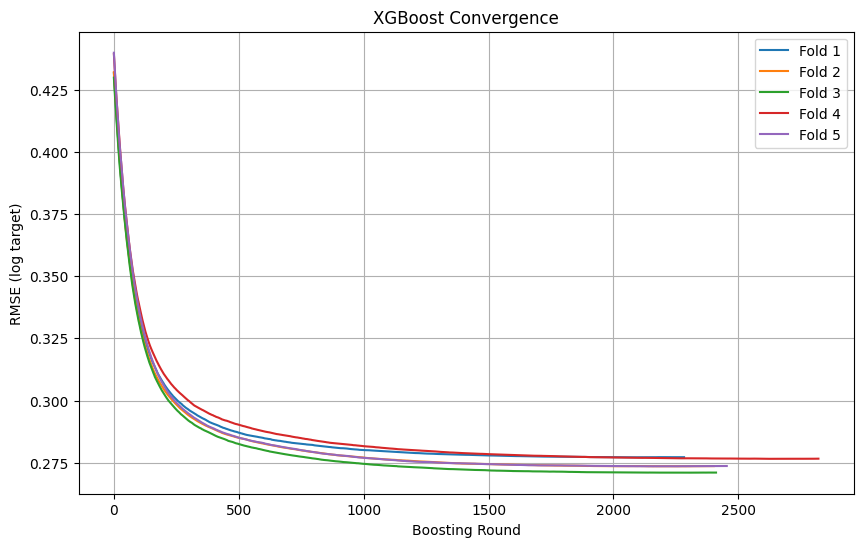

In [ ]:
cv_df = pd.DataFrame(fold_metrics)

print("\n========== Cross Validation ==========")
print(cv_df)

print("\nMean CV Metrics")

print(f"MAPE: {cv_df['MAPE'].mean()*100:.4f}%")
print(f"MAE : {cv_df['MAE'].mean():.4f}")
print(f"RMSE: {cv_df['RMSE'].mean():.4f}")
print(f"R2  : {cv_df['R2'].mean():.4f}")

overall = regression_metrics(y, oof_preds)

print("\n========== Overall OOF ==========")

print(f"OOF MAPE: {overall['MAPE']*100:.4f}%")
print(f"OOF MAE : {overall['MAE']:.4f}")
print(f"OOF RMSE: {overall['RMSE']:.4f}")
print(f"OOF R2  : {overall['R2']:.4f}")

plt.figure(figsize=(10,6))

for i, hist in enumerate(histories):
    val_rmse = hist["validation_1"]["rmse"]
    plt.plot(val_rmse,label=f"Fold {i+1}")

plt.xlabel("Boosting Round")
plt.ylabel("RMSE (log target)")
plt.title("XGBoost Convergence")
plt.legend()
plt.grid()
plt.show()

## PREDICTIONS

In [ ]:
test_original = pd.read_csv("test.csv")
test = pd.read_csv("test_final.csv")
test["FarmerID"] = test_original["FarmerID"]
test = test.loc[:, ~test.columns.str.contains("^Unnamed")]
farmer_ids = test["FarmerID"]


test = test.drop(columns=["FarmerID"], errors="ignore")
test = test.drop(columns=["Target_Variable/Total Income"], errors="ignore")


test = test[X.columns]
test[num_cols] = imputer.transform(test[num_cols])

test_preds = np.zeros(len(test))
for model in models:

    pred_log = model.predict(test)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    test_preds += pred

test_preds /= len(models)


submission = pd.DataFrame({
    "FarmerID": farmer_ids,
    "Target_Variable/Total Income": test_preds
})

submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")
print(submission.head())

Submission file created successfully!
           FarmerID  Target_Variable/Total Income
0  5015647759302590                   1220081.650
1  5831688977487240                   1074333.600
2  1741468197873020                   1174187.975
3  6437779104759020                   1108696.400
4  6093835744828620                    808319.375


###CUSTOM METRICS:

Calculating weights:

In [ ]:
def compute_weights(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Division by zero
    y_true = np.where(y_true == 0, 1e-6, y_true)

    return (np.abs(y_true - y_pred) / y_true) * (1 + 1 / np.log1p(y_true))

PMR Function:

In [ ]:
def compute_pmr(y_true, y_pred):
    fwri = compute_fwri(y_true, y_pred)
    weighted_error = fwri * np.abs(y_true - y_pred)
    return np.mean(weighted_error)


PMR Calculations:

In [ ]:
pmr_score = compute_pmr(y, oof_preds)

print("\nPMR (Poverty Misclassification Risk):", pmr_score)

relative_pmr = pmr_score / np.mean(y_train)
print("Relative PMR:", relative_pmr)


PMR (Poverty Misclassification Risk): 92421.97384068997
Relative PMR: 0.08470517249184036
